In [31]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px 
import seaborn as sns
sns.set(style="whitegrid")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error 
from sklearn import datasets


**Chargez visualisez et préparez vos données**

Quelle est la taille du jeu de données ?

Y a t-il des données manquantes ?

Les données sont-elles normalisées ?

Quelle est la distribution du health score ? Des autres features ?

In [32]:

data = datasets.load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [34]:
X.shape

(442, 10)

In [35]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


Text(0.5, 1.0, 'Distribution target')

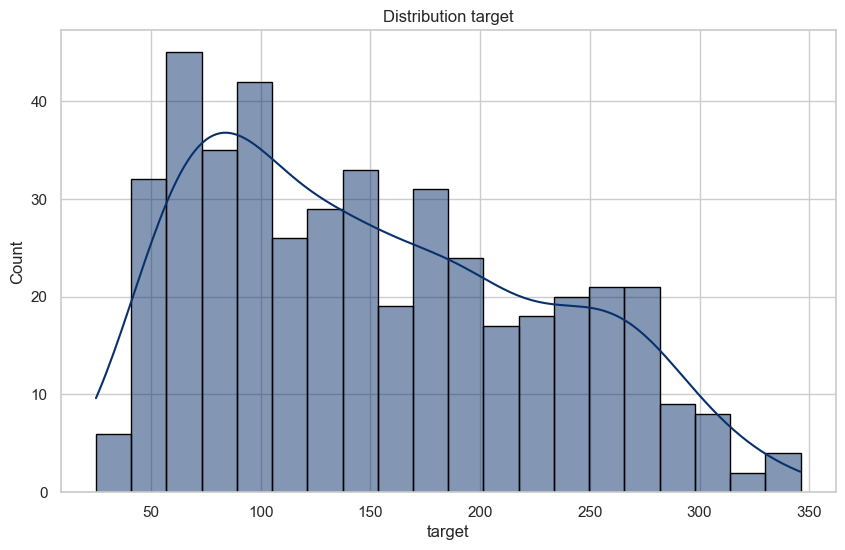

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(y,bins=20,color=plt.cm.Blues(1.0),edgecolor="black",kde=True)
plt.title("Distribution target")

<Figure size 1000x600 with 0 Axes>

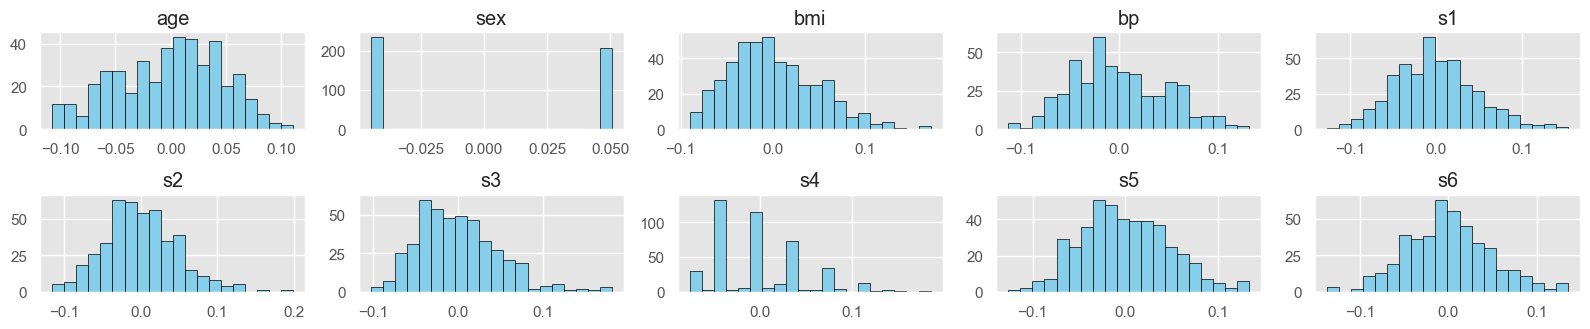

In [37]:
plt.figure(figsize=(10,6))
plt.style.use("ggplot")
X.hist(bins=20, color="skyblue", edgecolor="black", figsize=(16,8), layout=(5,5))
plt.tight_layout()
plt.show()

In [38]:
scaler = StandardScaler()
columns = X.columns
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=columns)



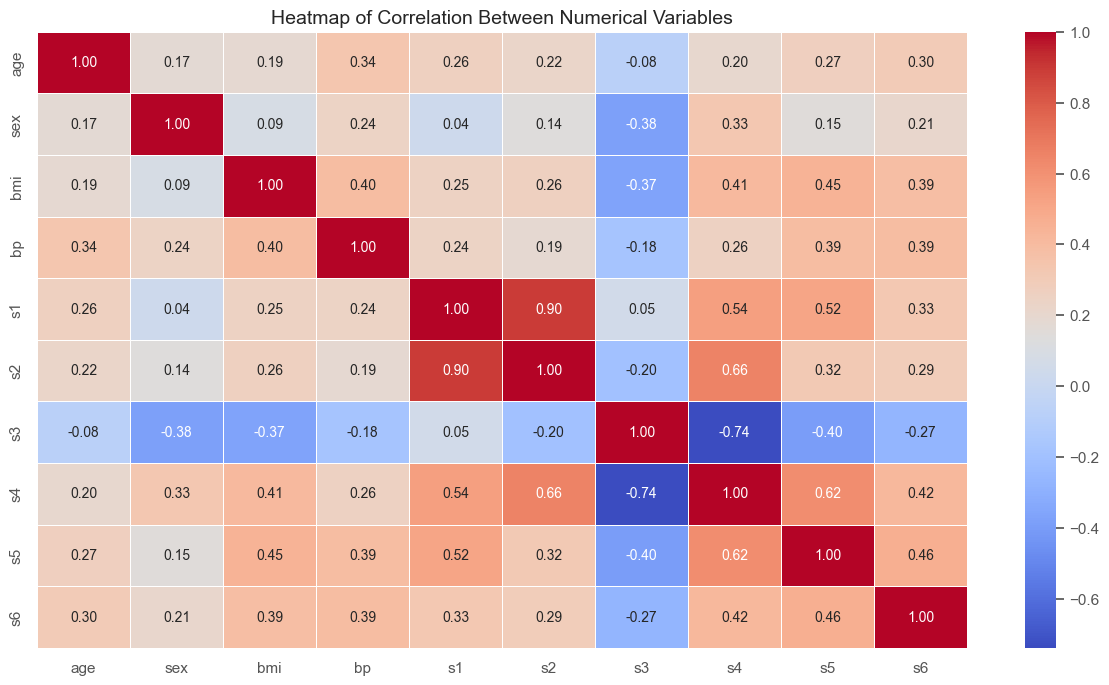

In [39]:
colmns = X.select_dtypes(include=['number'])
corr = colmns.corr()
plt.figure(figsize=(15, 8))  
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of Correlation Between Numerical Variables", fontsize=14)
plt.show()

In [40]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True)

#Splitted Data 0,25

print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (331, 10)
X_test shape is  (111, 10)
y_train shape is  (331,)
y_test shape is  (111,)


In [41]:

linreg = LinearRegression(fit_intercept=True,copy_X=True,n_jobs=-1)

In [42]:
linreg.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [43]:
y_pred_linreg = linreg.predict(X_test)
y_train_pred_linreg = linreg.predict(X_train)
y_pred_linreg

array([158.82583201, 211.81312297, 202.93161983,  68.40755596,
       168.37950718,  71.68886582, 162.58772829, 120.72775122,
       149.84065886, 283.6971852 , 188.31587157, 121.72934657,
       245.53887252, 259.72641208, 288.99195236, 102.93585061,
       170.9041443 ,  85.04067683, 121.44717487, 221.67650107,
       204.42473035, 158.75272222, 222.26565561, 216.50863721,
       157.11762321, 116.69070996, 104.45996611, 119.12780773,
       125.46880814, 193.987084  , 177.46478262, 248.84101203,
       144.14754313, 166.50099935, 102.2700471 , 257.14521396,
       115.05442417, 255.11633764,  86.14406415, 142.0864362 ,
        99.32239889, 171.47982546, 191.2812247 , 195.68340008,
       237.49942415, 147.99431105, 170.27133371,  82.49428733,
       182.84447559, 196.88859504, 113.20335601, 231.20933303,
       200.86200682, 124.01824593,  61.36084542, 234.19884285,
       153.42705023, 208.85618287, 232.09699504, 237.07692622,
        77.68277813, 133.71454509,  76.59862951, 142.88

In [44]:
mse = mean_squared_error(y_test, y_pred_linreg)
mae = mean_absolute_error(y_test, y_pred_linreg)
r2 = r2_score(y_test, y_pred_linreg)

print(f"Test MSE : {mse:.3f}")
print(f"Test MAE : {mae:.3f}")
print(f"Test R²  : {r2:.3f}")

train_mse = mean_squared_error(y_train, y_train_pred_linreg)
train_r2 = r2_score(y_train, y_train_pred_linreg)
print(f"Train MSE : {train_mse:.3f}, Train R² : {train_r2:.3f}")

Test MSE : 2815.244
Test MAE : 44.307
Test R²  : 0.487
Train MSE : 2888.853, Train R² : 0.520


In [45]:
residuals = y_test - y_pred_linreg
residuals_train = y_train - y_train_pred_linreg

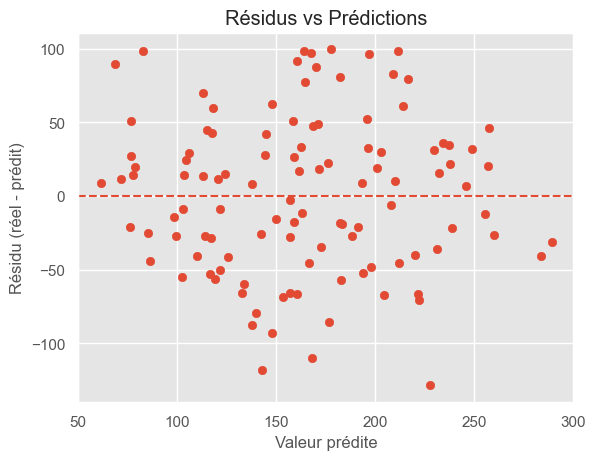

In [46]:
plt.figure()
plt.scatter(y_pred_linreg, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Valeur prédite")
plt.ylabel("Résidu (réel - prédit)")
plt.title("Résidus vs Prédictions")
plt.show()

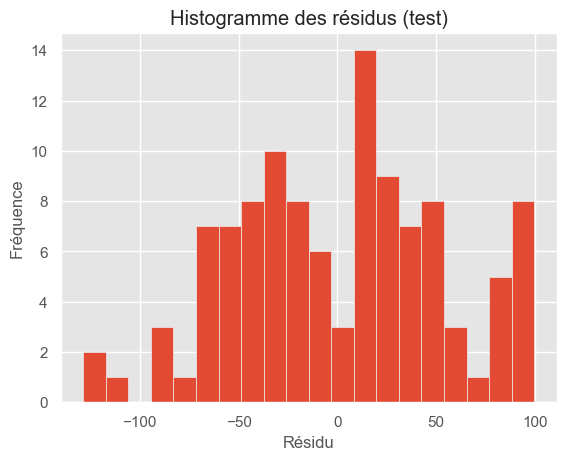

In [47]:
plt.figure()
plt.hist(residuals, bins=20)
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.title("Histogramme des résidus (test)")
plt.show()

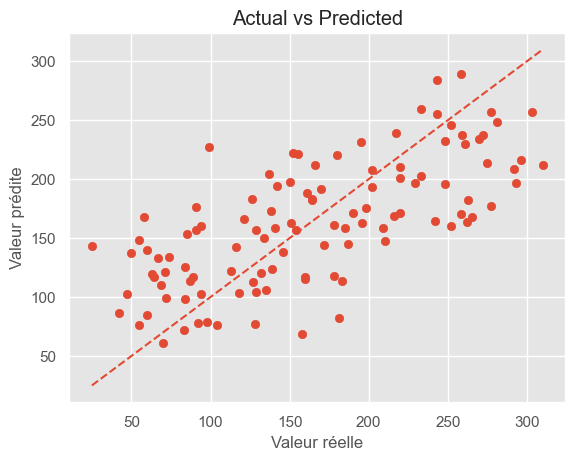

In [48]:
plt.figure()
plt.scatter(y_test, y_pred_linreg)
minv = min(y_test.min(), y_pred_linreg.min())
maxv = max(y_test.max(), y_pred_linreg.max())
plt.plot([minv, maxv], [minv, maxv], linestyle='--')
plt.xlabel("Valeur réelle")
plt.ylabel("Valeur prédite")
plt.title("Actual vs Predicted")
plt.show()

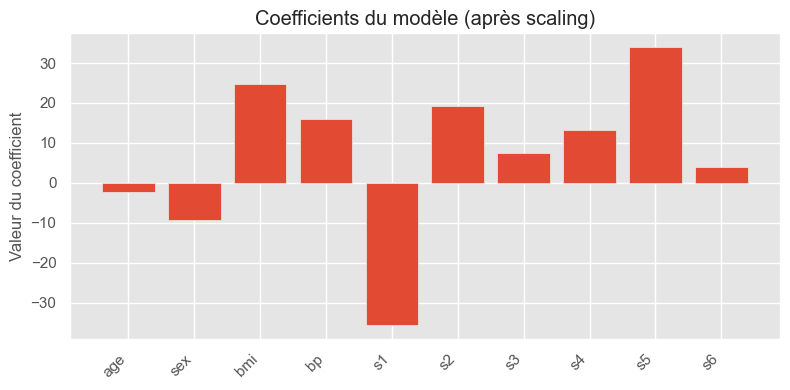

In [49]:
coefs = linreg.coef_
plt.figure(figsize=(8,4))
plt.bar(X.columns, coefs)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Valeur du coefficient")
plt.title("Coefficients du modèle (après scaling)")
plt.tight_layout()
plt.show()


Modèle Polynomial (deg=2) -> MSE: 3511.513, R²: 0.360


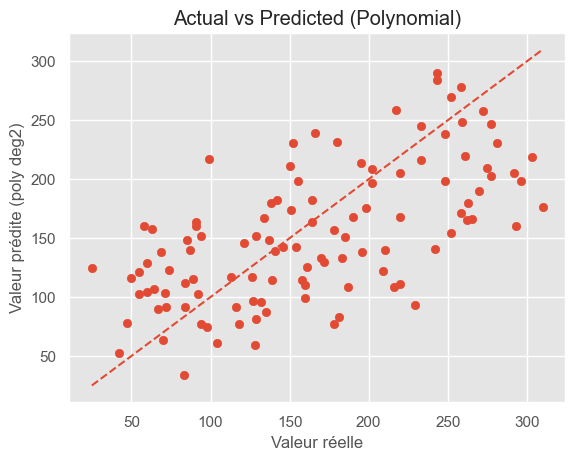

In [50]:


poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])
poly_pipeline.fit(X_train, y_train)
y_poly_pred = poly_pipeline.predict(X_test)

mse_poly = mean_squared_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)
print(f"\nModèle Polynomial (deg=2) -> MSE: {mse_poly:.3f}, R²: {r2_poly:.3f}")

plt.figure()
plt.scatter(y_test, y_poly_pred)
minv = min(y_test.min(), y_poly_pred.min())
maxv = max(y_test.max(), y_poly_pred.max())
plt.plot([minv, maxv], [minv, maxv], linestyle='--')
plt.xlabel("Valeur réelle")
plt.ylabel("Valeur prédite (poly deg2)")
plt.title("Actual vs Predicted (Polynomial)")
plt.show()

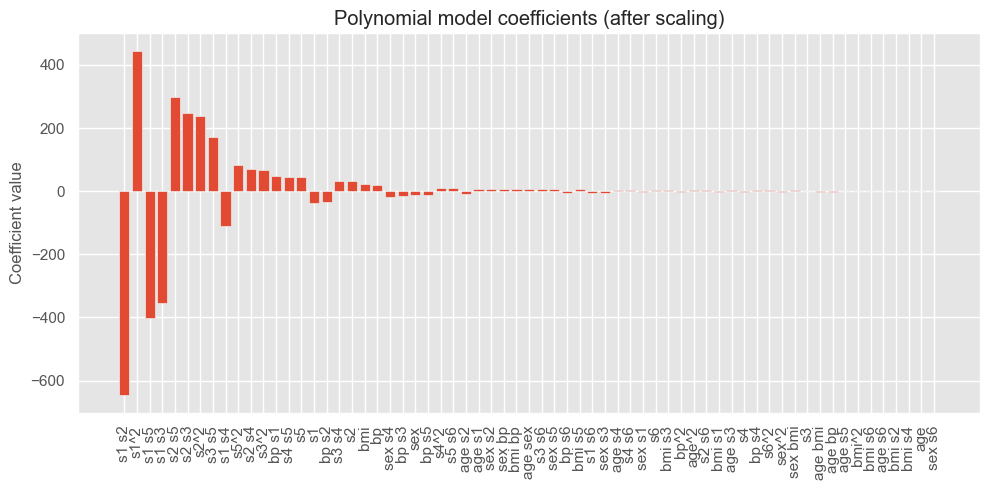

In [51]:
poly_feature_names = poly_pipeline.named_steps["poly"].get_feature_names_out(X.columns)
coefs = poly_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": poly_feature_names,
    "Coefficient": coefs
})

coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(10,5))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=90)
plt.ylabel("Coefficient value")
plt.title("Polynomial model coefficients (after scaling)")
plt.tight_layout()
plt.show()